# Flight Delay Prediction
## SMOTE to Handle Imbalance in ArrDel15
- <strong>Environment Setup:</strong> import libraries and load the dataset
- <strong>Imbalanced Data Analysis:</strong> understanding how the dataset balance is restored using random under sampling
- <strong>SMOTE:</strong> Creating synthetic data for the minority class using SMOTE(Synthetic Minority Over-sampling Technique), takes random samples from the minority class, finds its nearest k neighbors, and then selects a point between the randomly selected data point and its nearest k neighbors to generate synthetic data
- <strong>Inference:</strong> understand how the model produces results and choosing the best classifier

## Environment Setup

In [1]:
# Pre-requisites
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Store the classifier models to save time
import joblib

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Classifiers from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

# Performance metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Imbalanced dataset helpers
from imblearn.over_sampling import SMOTE


In [5]:
df = pd.read_csv("Data/flight_and_weather_encoded.csv", index_col=0)

## Dataset Without Handling Imbalance

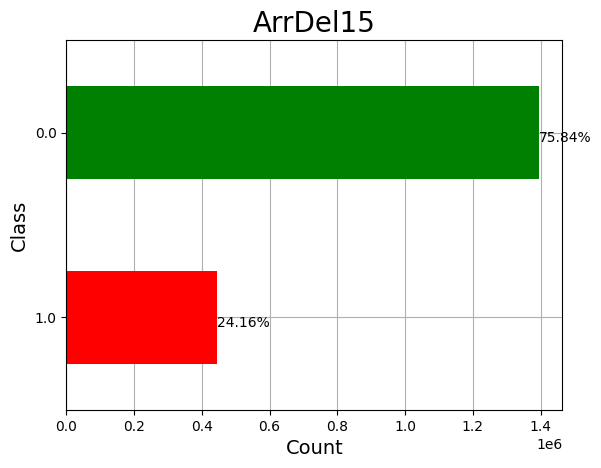

ArrDel15
0.0    1393948
1.0     443989
Name: count, dtype: int64


In [6]:
# Plotting the percentage of observations that fall under each class
ax = df["ArrDel15"].value_counts().sort_values().plot(kind="barh", color=["r", "g"])
ax.set_axisbelow(True)
ax.grid()
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
plt.title("ArrDel15", fontsize=20)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Class", fontsize=14)
plt.show()
print(df["ArrDel15"].value_counts())
fig = ax.get_figure()
fig.savefig("Img/09_01_Dataset_ArrDel15_Class_Imbalance.png")

In [ ]:
# features = df.loc[:, df.columns != "ArrDel15"]
# labels = np.asarray(df["ArrDel15"])
# # Number of samples/observations/rows is greater than 100,000
# print(f"\nDataset shape: {df.shape}")
# features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.20, random_state=42)
# print(f"features_train shape: {features_train.shape} | features_test shape: {features_test.shape}")
# print(f"labels_train shape: {labels_train.shape} | labels_test shape: {labels_test.shape}")
# # print(f"{features_train.shape[1]} Features: {features_train.columns.to_list()}")
# del features
# del labels


Dataset shape: (1851436, 24)
features_train shape: (1481148, 23) | features_test shape: (370288, 23)
labels_train shape: (1481148,) | labels_test shape: (370288,)


In [7]:
features = df.loc[:, df.columns != "ArrDel15"]
labels = np.asarray(df["ArrDel15"])
# Number of samples/observations/rows is greater than 100,000
print(f"\nDataset shape: {df.shape}")
features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.20, random_state=42)
print(f"features_train shape: {features_train.shape} | features_test shape: {features_test.shape}")
print(f"labels_train shape: {labels_train.shape} | labels_test shape: {labels_test.shape}")
# print(f"{features_train.shape[1]} Features: {features_train.columns.to_list()}")
del features
del labels


Dataset shape: (1837937, 24)
features_train shape: (1470349, 23) | features_test shape: (367588, 23)
labels_train shape: (1470349,) | labels_test shape: (367588,)


## Training Data Without Handling Imbalance

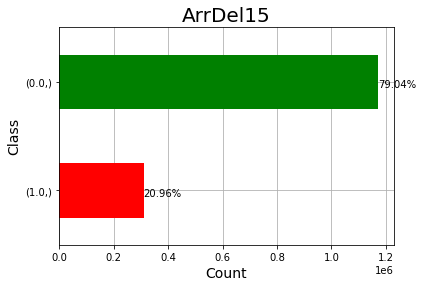

0.0    1170643
1.0     310505
dtype: int64


In [ ]:
# # Plotting the percentage of observations that fall under each class
# ax = pd.DataFrame(labels_train).value_counts().sort_values().plot(kind="barh", color=["r", "g"])
# ax.set_axisbelow(True)
# ax.grid()
# totals= []
# for i in ax.patches:
#     totals.append(i.get_width())
# total = sum(totals)
# for i in ax.patches:
#      ax.text(i.get_width()+.3, i.get_y()+.20, 
#      str(round((i.get_width()/total)*100, 2))+'%', 
#      fontsize=10, color='black')
# plt.title("ArrDel15", fontsize=20)
# plt.xlabel("Count", fontsize=14)
# plt.ylabel("Class", fontsize=14)
# plt.show()
# print(pd.DataFrame(labels_train).value_counts())
# fig = ax.get_figure()
# fig.savefig("Img/09_02_Training_ArrDel15_Class_Imbalance.png")

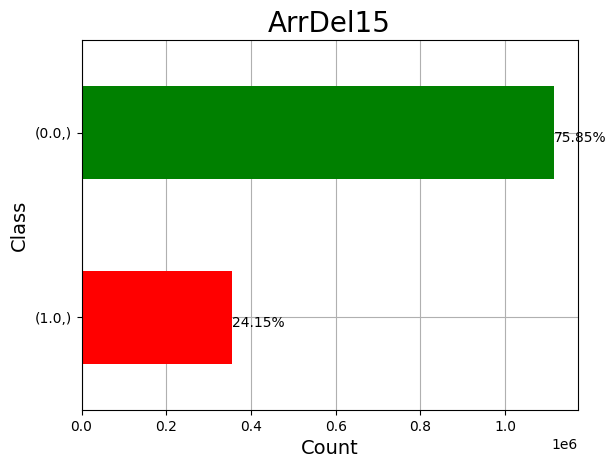

0  
0.0    1115249
1.0     355100
Name: count, dtype: int64


In [8]:
# Plotting the percentage of observations that fall under each class
ax = pd.DataFrame(labels_train).value_counts().sort_values().plot(kind="barh", color=["r", "g"])
ax.set_axisbelow(True)
ax.grid()
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
plt.title("ArrDel15", fontsize=20)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Class", fontsize=14)
plt.show()
print(pd.DataFrame(labels_train).value_counts())
fig = ax.get_figure()
fig.savefig("Img/09_02_Training_ArrDel15_Class_Imbalance.png")

## SMOTE

In [5]:
smote = SMOTE(random_state=42)
features_train, labels_train = smote.fit_resample(features_train, labels_train)

In [ ]:
# # SMOTE takes too long - approx 47 minutes
# # features_train.to_csv("./Data/smote_features_train.csv")
# # pd.DataFrame(labels_train).to_csv("./Data/smote_labels_train.csv")
# features_train = pd.read_csv("./Data/smote_features_train.csv", index_col=0)
# labels_train = pd.read_csv("./Data/smote_labels_train.csv", index_col=0)
# # labels_train.shape
# labels_train = labels_train["0"].values

In [6]:
# SMOTE takes too long - approx 47 minutes
features_train.to_csv("./Data/smote_features_train.csv")
pd.DataFrame(labels_train).to_csv("./Data/smote_labels_train.csv")

In [9]:
# SMOTE takes too long - approx 47 minutes
features_train = pd.read_csv("./Data/smote_features_train.csv", index_col=0)
labels_train = pd.read_csv("./Data/smote_labels_train.csv", index_col=0)
# labels_train.shape
labels_train = labels_train["0"].values

## Balancing the Training Data

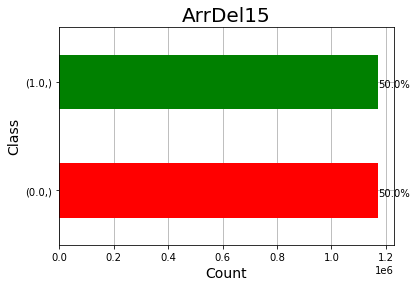

0.0    1170643
1.0    1170643
dtype: int64


In [ ]:
# # Plotting the percentage of observations that fall under each class
# ax = pd.DataFrame(labels_train).value_counts().sort_values().plot(kind="barh", color=["r", "g"])
# ax.set_axisbelow(True)
# ax.grid()
# totals= []
# for i in ax.patches:
#     totals.append(i.get_width())
# total = sum(totals)
# for i in ax.patches:
#      ax.text(i.get_width()+.3, i.get_y()+.20, 
#      str(round((i.get_width()/total)*100, 2))+'%', 
#      fontsize=10, color='black')
# plt.title("ArrDel15", fontsize=20)
# plt.xlabel("Count", fontsize=14)
# plt.ylabel("Class", fontsize=14)
# plt.show()
# print(pd.DataFrame(labels_train).value_counts())
# fig = ax.get_figure()
# fig.savefig("Img/09_03_SMOTE_Training_ArrDel15_Class.png")

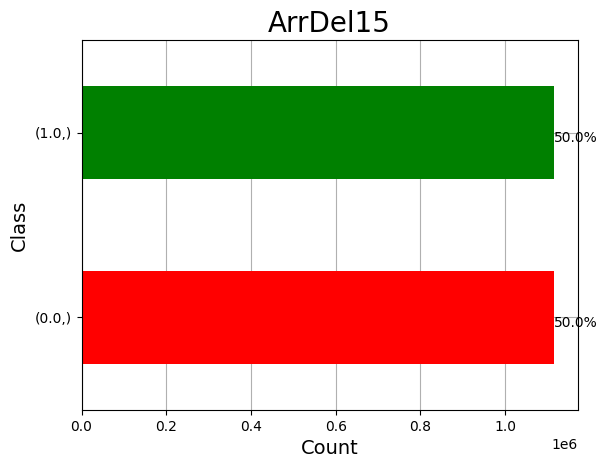

0  
0.0    1115249
1.0    1115249
Name: count, dtype: int64


In [10]:
# Plotting the percentage of observations that fall under each class
ax = pd.DataFrame(labels_train).value_counts().sort_values().plot(kind="barh", color=["r", "g"])
ax.set_axisbelow(True)
ax.grid()
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
plt.title("ArrDel15", fontsize=20)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Class", fontsize=14)
plt.show()
print(pd.DataFrame(labels_train).value_counts())
fig = ax.get_figure()
fig.savefig("Img/09_03_SMOTE_Training_ArrDel15_Class.png")

### Logistic Regression

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93    292735
         1.0       0.74      0.78      0.76     77553

    accuracy                           0.90    370288
   macro avg       0.84      0.85      0.85    370288
weighted avg       0.90      0.90      0.90    370288



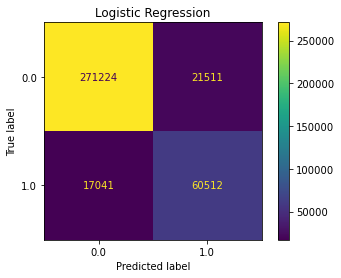

In [ ]:
# # model = LogisticRegression(n_jobs=-1)
# # model.fit(features_train, labels_train)
# # joblib.dump(model, "./SMOTE/LogisticRegression.joblib")
# model = joblib.load("./SMOTE/LogisticRegression.joblib")
# model_pred = model.predict(features_test)
# # print(confusion_matrix(labels_test, model_pred))
# print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
# plt.title("Logistic Regression")
# print(conf_mat_plot)
# plt.savefig("Img/09_04_SMOTE_LR_Confusion_Matrix")
# del model
# del model_pred

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93    278699
         1.0       0.77      0.79      0.78     88889

    accuracy                           0.89    367588
   macro avg       0.85      0.86      0.86    367588
weighted avg       0.89      0.89      0.89    367588



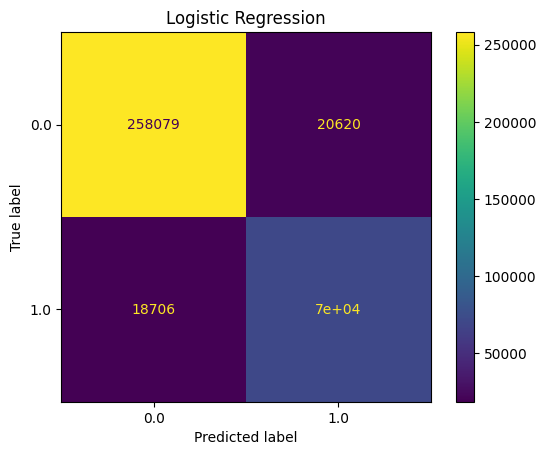

In [10]:
# model = LogisticRegression(n_jobs=-1)
# model.fit(features_train, labels_train)
# joblib.dump(model, "./SMOTE/LogisticRegression.joblib")
model = joblib.load("./SMOTE/LogisticRegression.joblib")
model_pred = model.predict(features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, features_test, labels_test)
plt.title("Logistic Regression")
print(conf_mat_plot)
plt.savefig("Img/09_04_SMOTE_LR_Confusion_Matrix")
del model
del model_pred

### Decision Tree Classifier

              precision    recall  f1-score   support

         0.0       0.92      0.90      0.91    292735
         1.0       0.66      0.71      0.68     77553

    accuracy                           0.86    370288
   macro avg       0.79      0.80      0.80    370288
weighted avg       0.87      0.86      0.86    370288



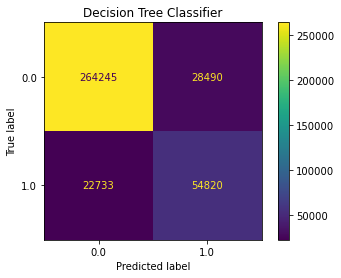

In [ ]:
# # model = DecisionTreeClassifier()
# # model.fit(features_train, labels_train)
# # joblib.dump(model, "./SMOTE/DecisionTreeClassifier.joblib")
# model = joblib.load("./SMOTE/DecisionTreeClassifier.joblib")
# model_pred = model.predict(features_test)
# # print(confusion_matrix(labels_test, model_pred))
# print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
# plt.title("Decision Tree Classifier")
# print(conf_mat_plot)
# plt.savefig("Img/09_05_SMOTE_DTC_Confusion_Matrix")
# del model
# del model_pred

              precision    recall  f1-score   support

         0.0       0.91      0.90      0.90    278699
         1.0       0.69      0.73      0.71     88889

    accuracy                           0.86    367588
   macro avg       0.80      0.81      0.81    367588
weighted avg       0.86      0.86      0.86    367588



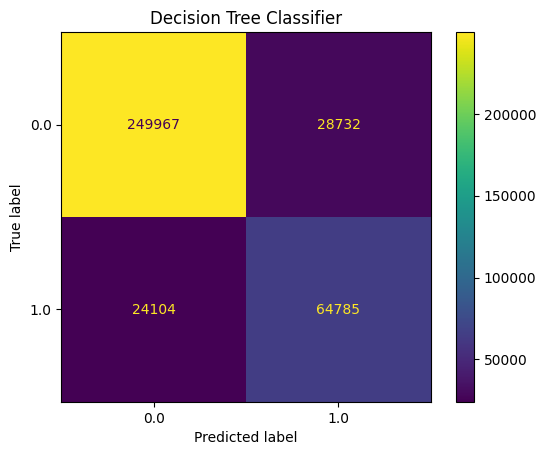

In [12]:
# model = DecisionTreeClassifier()
# model.fit(features_train, labels_train)
# joblib.dump(model, "./SMOTE/DecisionTreeClassifier.joblib")
model = joblib.load("./SMOTE/DecisionTreeClassifier.joblib")
model_pred = model.predict(features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, features_test, labels_test)

plt.title("Decision Tree Classifier")
print(conf_mat_plot)
plt.savefig("Img/09_05_SMOTE_DTC_Confusion_Matrix")
del model
del model_pred

### Gradient Boosting Classifier

              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94    292735
         1.0       0.80      0.75      0.77     77553

    accuracy                           0.91    370288
   macro avg       0.87      0.85      0.86    370288
weighted avg       0.91      0.91      0.91    370288



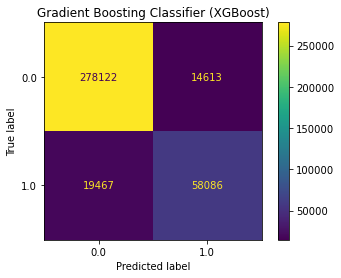

In [ ]:
# # model = GradientBoostingClassifier()
# # model.fit(features_train, labels_train)
# # joblib.dump(model, "./SMOTE/GradientBoostingClassifier.joblib")
# model = joblib.load("./SMOTE/GradientBoostingClassifier.joblib")
# model_pred = model.predict(features_test)
# # print(confusion_matrix(labels_test, model_pred))
# print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
# plt.title("Gradient Boosting Classifier (XGBoost)")
# print(conf_mat_plot)
# plt.savefig("Img/09_06_SMOTE_GBC_Confusion_Matrix")
# del model
# del model_pred

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94    278699
         1.0       0.84      0.76      0.79     88889

    accuracy                           0.91    367588
   macro avg       0.88      0.85      0.87    367588
weighted avg       0.90      0.91      0.90    367588



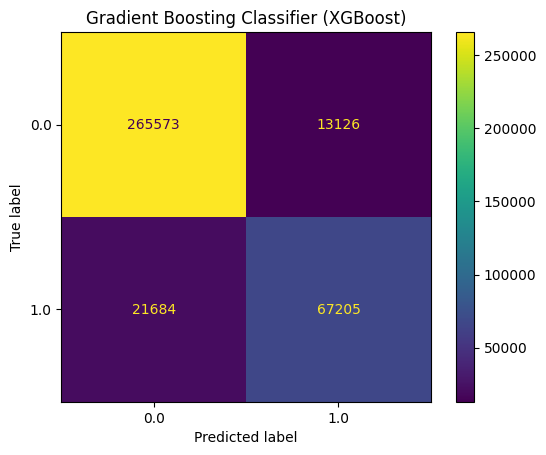

In [14]:
# model = GradientBoostingClassifier()
# model.fit(features_train, labels_train)
# joblib.dump(model, "./SMOTE/GradientBoostingClassifier.joblib")
model = joblib.load("./SMOTE/GradientBoostingClassifier.joblib")
model_pred = model.predict(features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, features_test, labels_test)

plt.title("Gradient Boosting Classifier (XGBoost)")
print(conf_mat_plot)
plt.savefig("Img/09_06_SMOTE_GBC_Confusion_Matrix")
del model
del model_pred

### Random Forest

              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94    292735
         1.0       0.81      0.74      0.78     77553

    accuracy                           0.91    370288
   macro avg       0.87      0.85      0.86    370288
weighted avg       0.91      0.91      0.91    370288



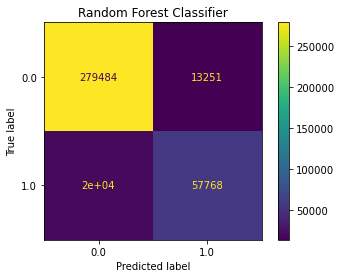

In [ ]:
# # model = RandomForestClassifier(n_jobs=-1)
# # model.fit(features_train, labels_train)
# # joblib.dump(model, "./SMOTE/RandomForestClassifier.joblib")
# model = joblib.load("./SMOTE/RandomForestClassifier.joblib")
# model_pred = model.predict(features_test)
# # print(confusion_matrix(labels_test, model_pred))
# print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
# plt.title("Random Forest Classifier")
# print(conf_mat_plot)
# plt.savefig("Img/09_07_SMOTE_RFC_Confusion_Matrix")
# del model
# del model_pred

              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94    278699
         1.0       0.83      0.76      0.79     88889

    accuracy                           0.91    367588
   macro avg       0.88      0.86      0.87    367588
weighted avg       0.90      0.91      0.90    367588



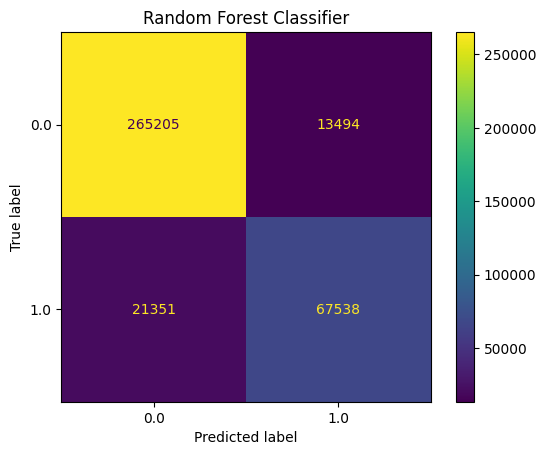

In [6]:
# model = RandomForestClassifier(n_jobs=-1)
# model.fit(features_train, labels_train)
# joblib.dump(model, "./SMOTE/RandomForestClassifier.joblib")
model = joblib.load("./SMOTE/RandomForestClassifier.joblib")
model_pred = model.predict(features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, features_test, labels_test)
plt.title("Random Forest Classifier")
print(conf_mat_plot)
plt.savefig("Img/09_07_SMOTE_RFC_Confusion_Matrix")
del model
del model_pred

### Extra Trees Classifier

              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94    292735
         1.0       0.77      0.76      0.76     77553

    accuracy                           0.90    370288
   macro avg       0.85      0.85      0.85    370288
weighted avg       0.90      0.90      0.90    370288



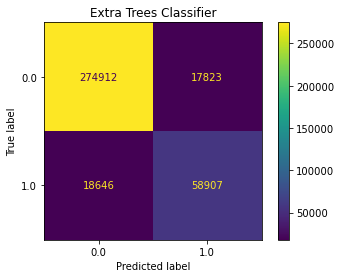

In [ ]:
# model = ExtraTreesClassifier(n_jobs=-1)
# model.fit(features_train, labels_train)
# # joblib.dump(model, "./SMOTE/ExtraTreesClassifier.joblib")
# # model = joblib.load("./SMOTE/ExtraTreesClassifier.joblib")
# model_pred = model.predict(features_test)
# # print(confusion_matrix(labels_test, model_pred))
# print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
# plt.title("Extra Trees Classifier")
# print(conf_mat_plot)
# plt.savefig("Img/09_08_SMOTE_ETC_Confusion_Matrix")

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93    278699
         1.0       0.78      0.78      0.78     88889

    accuracy                           0.89    367588
   macro avg       0.86      0.86      0.86    367588
weighted avg       0.89      0.89      0.89    367588



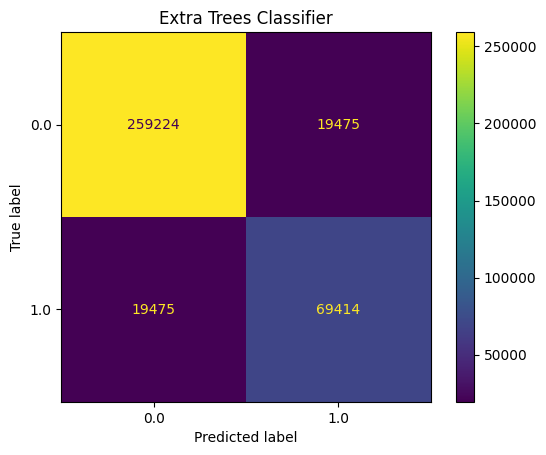

In [11]:
# model = ExtraTreesClassifier(n_jobs=-1)
# model.fit(features_train, labels_train)
# joblib.dump(model, "./SMOTE/ExtraTreesClassifier.joblib")
model = joblib.load("./SMOTE/ExtraTreesClassifier.joblib")
model_pred = model.predict(features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, features_test, labels_test)
plt.title("Extra Trees Classifier")
print(conf_mat_plot)
plt.savefig("Img/09_08_SMOTE_ETC_Confusion_Matrix")

## Performance Evaluation

In [ ]:
# # Setup
# perf_df = pd.DataFrame(columns=["classifiers", "fpr", "tpr", "auc"])

# # Handling Extra Trees Classifier separately due to memory constraints
# fpr, tpr, _ = roc_curve(labels_test,  model_pred)
# auc = roc_auc_score(labels_test, model_pred)
# # Record the results
# perf_df = perf_df.append({"classifiers": "ExtraTreesClassifier",
#                                         "fpr": fpr, 
#                                         "tpr": tpr, 
#                                         "auc": auc}, ignore_index=True)
# del model
# del model_pred

# classifiers = ["LogisticRegression", "DecisionTreeClassifier", "GradientBoostingClassifier", "RandomForestClassifier"]
# for clf in classifiers:
#     # Load the trained classifiers
#     model = joblib.load(f"./SMOTE/{clf}.joblib")
#     model_pred = model.predict(features_test)
#     fpr, tpr, _ = roc_curve(labels_test,  model_pred)
#     auc = roc_auc_score(labels_test, model_pred)
#     # Record the results
#     perf_df = perf_df.append({"classifiers": clf,
#                                         "fpr": fpr, 
#                                         "tpr": tpr, 
#                                         "auc": auc}, ignore_index=True)
#     del model
#     del model_pred

# # Set name of the classifiers as index labels
# perf_df.set_index("classifiers", inplace=True)

In [12]:
# Setup
perf_df = pd.DataFrame(columns=["classifiers", "fpr", "tpr", "auc"])

# Handling Extra Trees Classifier separately due to memory constraints
fpr, tpr, _ = roc_curve(labels_test,  model_pred)
auc = roc_auc_score(labels_test, model_pred)
# Record the results
perf_df = pd.concat([perf_df, pd.DataFrame([{
                                            "classifiers": "ExtraTreesClassifier",
                                            "fpr": fpr,
                                            "tpr": tpr,
                                            "auc": auc
                                        }])],ignore_index=True)
del model
del model_pred

classifiers = ["LogisticRegression", "DecisionTreeClassifier", "GradientBoostingClassifier", "RandomForestClassifier"]
for clf in classifiers:
    # Load the trained classifiers
    model = joblib.load(f"./SMOTE/{clf}.joblib")
    model_pred = model.predict(features_test)
    fpr, tpr, _ = roc_curve(labels_test,  model_pred)
    auc = roc_auc_score(labels_test, model_pred)
    # Record the results
    perf_df = pd.concat([perf_df, pd.DataFrame([{
                                                "classifiers": clf,
                                                "fpr": fpr,
                                                "tpr": tpr,
                                                "auc": auc
                                            }])], ignore_index=True)
    del model
    del model_pred

# Set name of the classifiers as index labels
perf_df.set_index("classifiers", inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_9300\982877791.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  perf_df = pd.concat([perf_df, pd.DataFrame([{


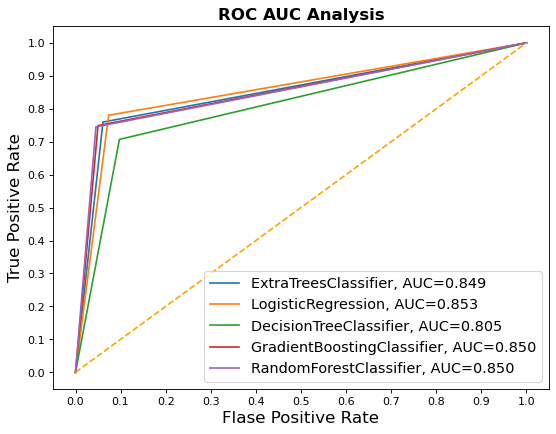

In [ ]:
# fig = plt.figure(figsize=(8,6), dpi=80)
# for clf_name in perf_df.index:
#     plt.plot(perf_df.loc[clf_name]["fpr"], 
#              perf_df.loc[clf_name]["tpr"], 
#              label="{}, AUC={:.3f}".format(clf_name, perf_df.loc[clf_name]["auc"]))
    
# plt.plot([0,1], [0,1], color='orange', linestyle='--')

# plt.xticks(np.arange(0.0, 1.1, step=0.1))
# plt.xlabel("Flase Positive Rate", fontsize=15)

# plt.yticks(np.arange(0.0, 1.1, step=0.1))
# plt.ylabel("True Positive Rate", fontsize=15)

# plt.title("ROC AUC Analysis", fontweight="bold", fontsize=15)
# plt.legend(prop={"size":13}, loc="lower right")

# fig.savefig("Img/09_09_SMOTE_Classifiers_AUC_ROC")
# plt.show()

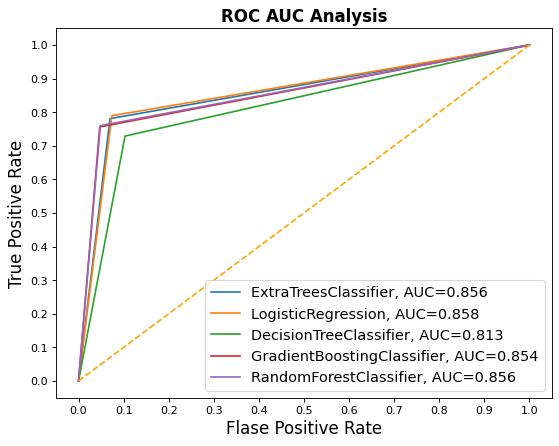

In [13]:
fig = plt.figure(figsize=(8,6), dpi=80)
for clf_name in perf_df.index:
    plt.plot(perf_df.loc[clf_name]["fpr"], 
             perf_df.loc[clf_name]["tpr"], 
             label="{}, AUC={:.3f}".format(clf_name, perf_df.loc[clf_name]["auc"]))
    
plt.plot([0,1], [0,1], color='orange', linestyle='--')

plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("Flase Positive Rate", fontsize=15)

plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)

plt.title("ROC AUC Analysis", fontweight="bold", fontsize=15)
plt.legend(prop={"size":13}, loc="lower right")

fig.savefig("Img/09_09_SMOTE_Classifiers_AUC_ROC")
plt.show()

## Inference
<table>
    <thead>
        <tr>
            <th rowspan="3">Classification Model</th>
            <th colspan="8">Performance Metric</th>
        </tr>
        <tr>
            <th colspan="2">Precision</th>
            <th colspan="2">Recall</th>
            <th colspan="2">F1 Score</th>
            <th rowspan="2" colspan="2">Accuracy</th>
        </tr>
        <tr>
            <th>0.0</th>
            <th>1.0</th>
            <th>0.0</th>
            <th>1.0</th>
            <th>0.0</th>
            <th>1.0</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th>Logistic Regression</th>
            <td>0.94</td>
            <td>0.74</td>
            <td>0.93</td>
            <td>0.78</td>
            <td>0.93</td>
            <td>0.76</td>
            <td>0.90</td>
        </tr>
        <tr>
            <th>Decision Tree Classifier</th>
            <td>0.92</td>
            <td>0.66</td>
            <td>0.90</td>
            <td>0.71</td>
            <td>0.91</td>
            <td>0.68</td>
            <td>0.86</td>
        </tr>
        <tr>
            <th>Extra Trees Classifier</th>
            <td>0.94</td>
            <td>0.77</td>
            <td>0.94</td>
            <td>0.76</td>
            <td>0.94</td>
            <td>0.76</td>
            <td>0.90</td>
        </tr>
        <tr>
            <th>Gradient Boosting Classifier</th>
            <td>0.93</td>
            <td>0.80</td>
            <td>0.95</td>
            <td>0.75</td>
            <td>0.94</td>
            <td>0.77</td>
            <td>0.91</td>
        </tr>
        <tr>
            <th>Random Forest Classifier</th>
            <td>0.93</td>
            <td>0.81</td>
            <td>0.95</td>
            <td>0.74</td>
            <td>0.94</td>
            <td>0.78</td>
            <td>0.91</td>
        </tr>
    </tbody>
</table>